# Machine Learning Regression

In [406]:
%pip install pandas numpy


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [407]:
%pip list

Package                 Version
----------------------- -----------
appnope                 0.1.4
asttokens               3.0.1
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.19
decorator               5.2.1
executing               2.2.1
fonttools               4.61.1
ipykernel               7.1.0
ipython                 9.9.0
ipython_pygments_lexers 1.1.1
jedi                    0.19.2
jupyter_client          8.8.0
jupyter_core            5.9.1
kiwisolver              1.4.9
matplotlib              3.10.8
matplotlib-inline       0.2.1
nest-asyncio            1.6.0
numpy                   2.4.1
packaging               26.0
pandas                  3.0.0
parso                   0.8.5
pexpect                 4.9.0
pillow                  12.1.0
pip                     25.3
platformdirs            4.5.1
prompt_toolkit          3.0.52
psutil                  7.2.1
ptyprocess              0.7.0
pure_eval               0.2

In [408]:
import pandas as pd
import numpy as np

# 2.2 Data Preparation

In [409]:
data = 'https://raw.githubusercontent.com/sithvothykiv/ml-dataset/refs/heads/main/car_dataset.csv'
!wget -O car_dataset.csv $data

--2026-02-08 16:28:04--  https://raw.githubusercontent.com/sithvothykiv/ml-dataset/refs/heads/main/car_dataset.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1475504 (1.4M) [text/plain]
Saving to: 'car_dataset.csv'

car_dataset.csv     100%[===================>]   1.41M  7.80MB/s    in 0.2s    

2026-02-08 16:28:05 (7.80 MB/s) - 'car_dataset.csv' saved [1475504/1475504]



In [410]:
df = pd.read_csv('car_dataset.csv')
df

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,46120
11910,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,56670
11911,Acura,ZDX,2012,premium unleaded (required),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50620
11912,Acura,ZDX,2013,premium unleaded (recommended),300.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Hatchback,Luxury",Midsize,4dr Hatchback,23,16,204,50920


In [411]:
df.head(2)

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650


In [412]:
df.loc[100]

Make                           Nissan
Model                           240SX
Year                             1997
Engine Fuel Type     regular unleaded
Engine HP                       155.0
Engine Cylinders                  4.0
Transmission Type              MANUAL
Driven_Wheels        rear wheel drive
Number of Doors                   2.0
Market Category           Performance
Vehicle Size                  Compact
Vehicle Style                   Coupe
highway MPG                        26
city mpg                           19
Popularity                       2009
MSRP                             4107
Name: 100, dtype: object

In [413]:
df[100:200]

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
100,Nissan,240SX,1997,regular unleaded,155.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Coupe,26,19,2009,4107
101,Nissan,240SX,1998,regular unleaded,155.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Coupe,25,20,2009,4299
102,Nissan,240SX,1998,regular unleaded,155.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Coupe,25,20,2009,4693
103,Nissan,240SX,1998,regular unleaded,155.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Coupe,25,20,2009,4107
104,Volvo,240,1991,regular unleaded,114.0,4.0,MANUAL,rear wheel drive,4.0,Luxury,Midsize,Wagon,26,19,870,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Mitsubishi,3000GT,1997,regular unleaded,161.0,6.0,MANUAL,front wheel drive,2.0,Hatchback,Compact,2dr Hatchback,22,17,436,3295
196,Mitsubishi,3000GT,1997,regular unleaded,320.0,6.0,MANUAL,all wheel drive,2.0,"Hatchback,Factory Tuner,Performance",Compact,2dr Hatchback,22,16,436,6008
197,Mitsubishi,3000GT,1998,regular unleaded,320.0,6.0,MANUAL,all wheel drive,2.0,"Hatchback,Factory Tuner,Performance",Compact,2dr Hatchback,22,16,436,6710
198,Mitsubishi,3000GT,1998,regular unleaded,161.0,6.0,MANUAL,front wheel drive,2.0,Hatchback,Compact,2dr Hatchback,22,17,436,3701


In [414]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [415]:
df.columns = df.columns.str.lower().str.replace(' ' , '_')

In [416]:
df['vehicle_size']

0        Compact
1        Compact
2        Compact
3        Compact
4        Compact
          ...   
11909    Midsize
11910    Midsize
11911    Midsize
11912    Midsize
11913    Midsize
Name: vehicle_size, Length: 11914, dtype: str

In [417]:
df.dtypes == 'object'

make                 False
model                False
year                 False
engine_fuel_type     False
engine_hp            False
engine_cylinders     False
transmission_type    False
driven_wheels        False
number_of_doors      False
market_category      False
vehicle_size         False
vehicle_style        False
highway_mpg          False
city_mpg             False
popularity           False
msrp                 False
dtype: bool

In [418]:
strings = list(df.dtypes.index)
strings

['make',
 'model',
 'year',
 'engine_fuel_type',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'driven_wheels',
 'number_of_doors',
 'market_category',
 'vehicle_size',
 'vehicle_style',
 'highway_mpg',
 'city_mpg',
 'popularity',
 'msrp']

In [419]:
df.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
msrp                   int64
dtype: object

In [420]:
df.make, df.msrp.loc[10:20]

(0            BMW
 1            BMW
 2            BMW
 3            BMW
 4            BMW
           ...   
 11909      Acura
 11910      Acura
 11911      Acura
 11912      Acura
 11913    Lincoln
 Name: make, Length: 11914, dtype: str,
 10    39600
 11    31500
 12    44400
 13    37200
 14    31500
 15    48250
 16    43550
 17     2000
 18     2000
 19     2000
 20     2000
 Name: msrp, dtype: int64)

# 2.3 EDA - Exploratory Data Analysis

In [421]:
strings

['make',
 'model',
 'year',
 'engine_fuel_type',
 'engine_hp',
 'engine_cylinders',
 'transmission_type',
 'driven_wheels',
 'number_of_doors',
 'market_category',
 'vehicle_size',
 'vehicle_style',
 'highway_mpg',
 'city_mpg',
 'popularity',
 'msrp']

In [422]:
for col in strings:
    df[col]
# df[col]

In [423]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5]) # display value of unique column
    print(df[col].nunique()) # display number of unique column

make
<StringArray>
['BMW', 'Audi', 'FIAT', 'Mercedes-Benz', 'Chrysler']
Length: 5, dtype: str
48
model
<StringArray>
['1 Series M', '1 Series', '100', '124 Spider', '190-Class']
Length: 5, dtype: str
915
year
[2011 2012 2013 1992 1993]
28
engine_fuel_type
<StringArray>
[   'premium unleaded (required)',               'regular unleaded',
 'premium unleaded (recommended)',       'flex-fuel (unleaded/E85)',
                         'diesel']
Length: 5, dtype: str
10
engine_hp
[335. 300. 230. 320. 172.]
356
engine_cylinders
[ 6.  4.  5.  8. 12.]
9
transmission_type
<StringArray>
['MANUAL', 'AUTOMATIC', 'AUTOMATED_MANUAL', 'DIRECT_DRIVE', 'UNKNOWN']
Length: 5, dtype: str
5
driven_wheels
<StringArray>
['rear wheel drive', 'front wheel drive', 'all wheel drive',
 'four wheel drive']
Length: 4, dtype: str
4
number_of_doors
[ 2.  4.  3. nan]
3
market_category
<StringArray>
['Factory Tuner,Luxury,High-Performance',
                    'Luxury,Performance',
               'Luxury,High-Performance

In [424]:
%pip install seaborn matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [425]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='msrp', ylabel='Count'>

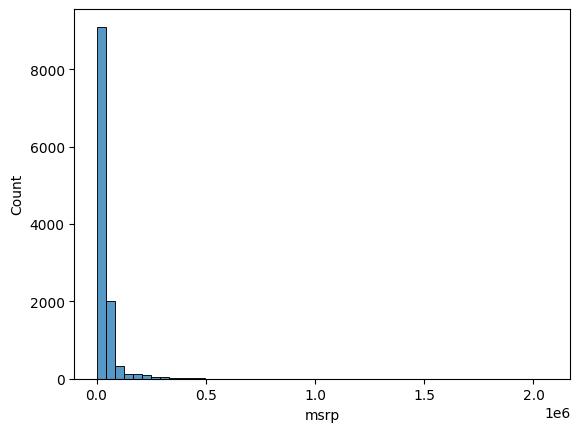

In [426]:
sns.histplot(df.msrp, bins=50)

In [427]:
df.msrp.max()

np.int64(2065902)

<Axes: xlabel='msrp', ylabel='Count'>

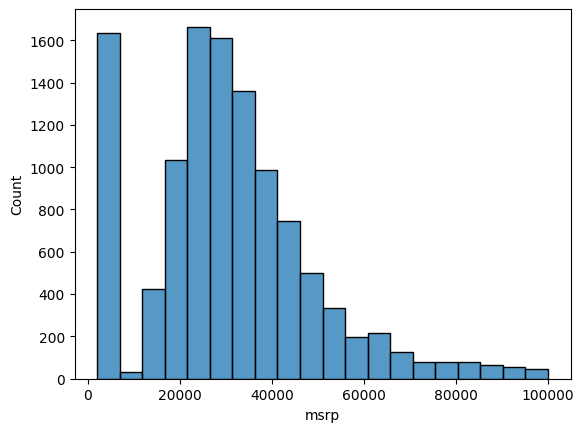

In [428]:
sns.histplot(df.msrp[df.msrp < 100000], bins=20)

<Axes: xlabel='highway_mpg', ylabel='Count'>

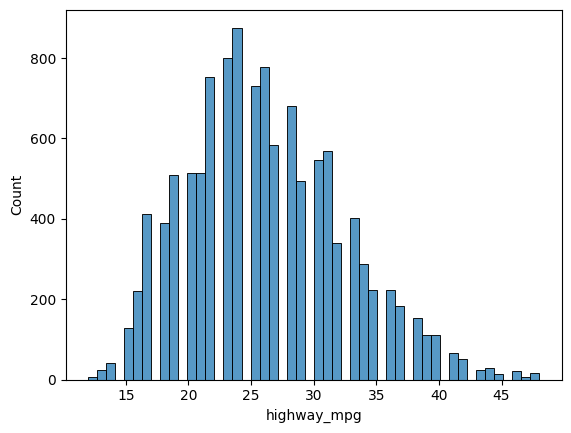

In [429]:
sns.histplot(df.highway_mpg[df.highway_mpg < 50], bins=50)

In [430]:
np.log([0, 1, 10, 1000, 100000])

/var/folders/f4/cl_5bc4s0r593l2b3w2mgd_w0000gp/T/ipykernel_1528/1040805571.py:1: RuntimeWarning: divide by zero encountered in log
  np.log([0, 1, 10, 1000, 100000])


array([       -inf,  0.        ,  2.30258509,  6.90775528, 11.51292546])

In [431]:
np.log1p([0, 1, 10, 1000, 100000])

array([ 0.        ,  0.69314718,  2.39789527,  6.90875478, 11.51293546])

In [432]:
df.msrp

0        46135
1        40650
2        36350
3        29450
4        34500
         ...  
11909    46120
11910    56670
11911    50620
11912    50920
11913    28995
Name: msrp, Length: 11914, dtype: int64

In [433]:
df.msrp

0        46135
1        40650
2        36350
3        29450
4        34500
         ...  
11909    46120
11910    56670
11911    50620
11912    50920
11913    28995
Name: msrp, Length: 11914, dtype: int64

In [434]:
price_log = np.log(df.msrp)
price_log

0        10.739327
1        10.612754
2        10.500949
3        10.290449
4        10.448715
           ...    
11909    10.739002
11910    10.945000
11911    10.832102
11912    10.838011
11913    10.274879
Name: msrp, Length: 11914, dtype: float64

In [435]:
price_logs = np.log1p(df.msrp)
price_logs

0        10.739349
1        10.612779
2        10.500977
3        10.290483
4        10.448744
           ...    
11909    10.739024
11910    10.945018
11911    10.832122
11912    10.838031
11913    10.274913
Name: msrp, Length: 11914, dtype: float64

<Axes: xlabel='msrp', ylabel='Count'>

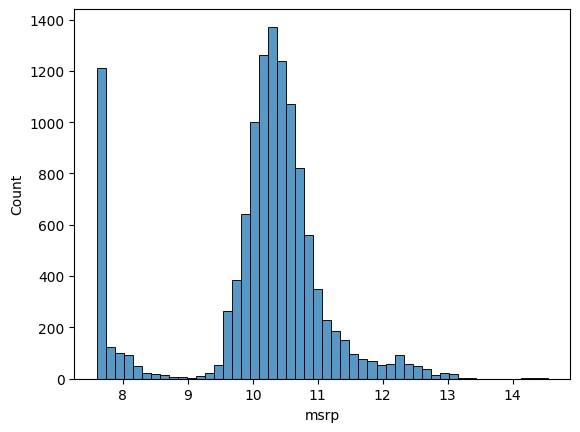

In [436]:
sns.histplot(price_logs, bins=50)

# Missing value

In [437]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

# 2.4 Validation Framework

In [438]:
# Pandas, NumPy
df.iloc[:10]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
5,BMW,1 Series,2012,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,31200
6,BMW,1 Series,2012,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,26,17,3916,44100
7,BMW,1 Series,2012,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,39300
8,BMW,1 Series,2012,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,36900
9,BMW,1 Series,2013,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,27,18,3916,37200


In [439]:
# total records
len(df)

11914

In [440]:
# 20% of total records
int(len(df)*0.2)

2382

In [441]:
n = len(df)
n_val = n_test = int(n*0.2)
n_train = n - n_val - n_test
# n, n_val, n_test, n_train

print('total records', n)

print('validation records 20%',n_val)
print('test records 20%',n_test)
print('total train records', n_train)

total records 11914
validation records 20% 2382
test records 20% 2382
total train records 7150


In [442]:
df.iloc[:n_train]

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,Mazda,Navajo,1994,regular unleaded,160.0,6.0,MANUAL,four wheel drive,2.0,NaN,Compact,2dr SUV,18,14,586,2000
7146,Mazda,Navajo,1994,regular unleaded,160.0,6.0,MANUAL,four wheel drive,2.0,NaN,Compact,2dr SUV,18,14,586,2000
7147,Lincoln,Navigator,2015,regular unleaded,365.0,6.0,AUTOMATIC,four wheel drive,4.0,Luxury,Large,4dr SUV,20,15,61,65055
7148,Lincoln,Navigator,2015,regular unleaded,365.0,6.0,AUTOMATIC,four wheel drive,4.0,Luxury,Large,4dr SUV,19,15,61,67220


In [443]:
idx = np.arange(n)
idx

array([    0,     1,     2, ..., 11911, 11912, 11913], shape=(11914,))

In [444]:
np.random.shuffle(idx)
idx

array([ 6044,  4993, 11881, ...,   670,  1460,  5122], shape=(11914,))

In [445]:
df_train = df.iloc[idx[:n_train]] # 0 .... 7150
df_val = df.iloc[idx[n_train:n_train+n_val]] # 7150 .... +2382
df_test = df.iloc[idx[n_train + n_val:]] # 80% ... +20%

In [446]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
6044,Volkswagen,Jetta Hybrid,2013,premium unleaded (required),170.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Hybrid,Midsize,Sedan,48,42,873,26990
4993,Nissan,Frontier,2016,regular unleaded,261.0,6.0,MANUAL,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,21,16,2009,28890
11881,BMW,Z3,2000,regular unleaded,193.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,24,17,3916,4976
9701,Pontiac,Solstice,2008,regular unleaded,173.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Convertible,25,19,210,22455
665,BMW,6 Series,2017,premium unleaded (required),315.0,6.0,AUTOMATIC,all wheel drive,2.0,"Luxury,Performance",Midsize,Coupe,28,19,3916,80600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7456,Volkswagen,Passat,2015,regular unleaded,170.0,4.0,AUTOMATIC,front wheel drive,4.0,NaN,Midsize,Sedan,36,24,873,24375
5696,HUMMER,H3,2009,regular unleaded,242.0,5.0,AUTOMATIC,four wheel drive,4.0,Luxury,Midsize,4dr SUV,18,14,130,43130
10487,Acura,TL,2014,premium unleaded (recommended),305.0,6.0,AUTOMATIC,all wheel drive,4.0,"Luxury,Performance",Midsize,Sedan,26,18,204,43310
4874,Kia,Forte,2016,regular unleaded,173.0,4.0,AUTOMATIC,front wheel drive,2.0,NaN,Compact,Coupe,34,25,1720,19890


In [447]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [448]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,Volkswagen,Jetta Hybrid,2013,premium unleaded (required),170.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Hybrid,Midsize,Sedan,48,42,873,26990
1,Nissan,Frontier,2016,regular unleaded,261.0,6.0,MANUAL,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,21,16,2009,28890
2,BMW,Z3,2000,regular unleaded,193.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,24,17,3916,4976
3,Pontiac,Solstice,2008,regular unleaded,173.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Convertible,25,19,210,22455
4,BMW,6 Series,2017,premium unleaded (required),315.0,6.0,AUTOMATIC,all wheel drive,2.0,"Luxury,Performance",Midsize,Coupe,28,19,3916,80600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,Volkswagen,Passat,2015,regular unleaded,170.0,4.0,AUTOMATIC,front wheel drive,4.0,NaN,Midsize,Sedan,36,24,873,24375
7146,HUMMER,H3,2009,regular unleaded,242.0,5.0,AUTOMATIC,four wheel drive,4.0,Luxury,Midsize,4dr SUV,18,14,130,43130
7147,Acura,TL,2014,premium unleaded (recommended),305.0,6.0,AUTOMATIC,all wheel drive,4.0,"Luxury,Performance",Midsize,Sedan,26,18,204,43310
7148,Kia,Forte,2016,regular unleaded,173.0,4.0,AUTOMATIC,front wheel drive,2.0,NaN,Compact,Coupe,34,25,1720,19890


In [449]:
df_val.msrp.values

array([  3099,  44560,  67600, ..., 117530,  34700,  89000], shape=(2382,))

In [450]:
y_train = df_train.msrp.values
y_val = df_val.msrp.values
y_test = df_test.msrp.values

In [451]:
df_train.msrp[:10]

0    26990
1    28890
2     4976
3    22455
4    80600
5    22680
6    16999
7    24595
8    32095
9    24895
Name: msrp, dtype: int64

In [452]:
value_log = np.log1p(df_train.msrp[:10])
value_log

0    10.203259
1    10.271285
2     8.512583
3    10.019313
4    11.297266
5    10.029283
6     9.740969
7    10.110339
8    10.376487
9    10.122462
Name: msrp, dtype: float64

In [453]:
np.e

2.718281828459045

In [454]:
n_train

7150

In [455]:
# y, or traget variable
# convert to logarithm

y_train = np.log1p(df_train.msrp.values) # 7150
y_val = np.log1p(df_val.msrp.values) # 2382
y_test = np.log1p(df_test.msrp.values) # 2382

In [456]:
y_pred

array([ 9.7039377 , 12.165075  , 10.43700916, ...,  9.25834512,
        9.49780532,  7.90557174], shape=(2382,))

In [457]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,Ford,F-250,1998,regular unleaded,220.0,8.0,MANUAL,four wheel drive,2.0,NaN,Large,Regular Cab Pickup,16,13,5657,3099
1,Lincoln,Continental,2017,regular unleaded,305.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Large,Sedan,26,17,61,44560
2,Land Rover,Range Rover Sport,2014,flex-fuel (premium unleaded required/E85),340.0,6.0,AUTOMATIC,four wheel drive,4.0,"Flex Fuel,Luxury,Performance",Midsize,4dr SUV,23,17,258,67600
3,BMW,4 Series,2015,premium unleaded (required),240.0,4.0,AUTOMATIC,rear wheel drive,2.0,Luxury,Midsize,Convertible,34,23,3916,48750
4,Volkswagen,Passat,2015,diesel,150.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Diesel,Midsize,Sedan,42,30,873,33925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,Infiniti,G Sedan,2012,premium unleaded (recommended),328.0,6.0,AUTOMATIC,all wheel drive,4.0,Luxury,Midsize,Sedan,25,18,190,41850
2378,Volkswagen,Golf GTI,2016,premium unleaded (recommended),210.0,4.0,AUTOMATED_MANUAL,front wheel drive,2.0,"Hatchback,Performance",Compact,2dr Hatchback,33,25,873,29125
2379,Porsche,911,2016,premium unleaded (required),400.0,6.0,MANUAL,all wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,26,18,1715,117530
2380,Toyota,Tacoma,2016,regular unleaded,278.0,6.0,AUTOMATIC,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,23,18,2031,34700


In [458]:
# X, feature matrix
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [459]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,Volkswagen,Jetta Hybrid,2013,premium unleaded (required),170.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Hybrid,Midsize,Sedan,48,42,873
1,Nissan,Frontier,2016,regular unleaded,261.0,6.0,MANUAL,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,21,16,2009
2,BMW,Z3,2000,regular unleaded,193.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,24,17,3916
3,Pontiac,Solstice,2008,regular unleaded,173.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Convertible,25,19,210
4,BMW,6 Series,2017,premium unleaded (required),315.0,6.0,AUTOMATIC,all wheel drive,2.0,"Luxury,Performance",Midsize,Coupe,28,19,3916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,Volkswagen,Passat,2015,regular unleaded,170.0,4.0,AUTOMATIC,front wheel drive,4.0,NaN,Midsize,Sedan,36,24,873
7146,HUMMER,H3,2009,regular unleaded,242.0,5.0,AUTOMATIC,four wheel drive,4.0,Luxury,Midsize,4dr SUV,18,14,130
7147,Acura,TL,2014,premium unleaded (recommended),305.0,6.0,AUTOMATIC,all wheel drive,4.0,"Luxury,Performance",Midsize,Sedan,26,18,204
7148,Kia,Forte,2016,regular unleaded,173.0,4.0,AUTOMATIC,front wheel drive,2.0,NaN,Compact,Coupe,34,25,1720


# 2.5 linear regression

In [460]:
!pwd

/Users/kivsithvothy/Downloads/ml-regression-W3


![Alt text for the image](Screenshot%202026-02-01%20at%203.14.07%20pm.png)

In [461]:
len(y_train) # 7150
len(y_val) # 2382
len(y_test) # 2382

2382

In [462]:
# engine_hp, city_mpg, popularity
xi = [453, 11, 86]
w0 = 0
w = [0.01, 0.04, 0.002]

In [463]:
def linear_regression(xi):
    n = len(xi)

    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]

    return pred

In [464]:
predicted_price = linear_regression(xi)
predicted_price # 5.142

5.142

In [465]:
np.expm1(predicted_price) # 170.0575415172371

np.float64(170.0575415172371)

In [466]:
xi = [453, 11, 86] # example input, engine_hp, city_mpg, popularity
w0 = 7.17 # Bias Term
w = [0.01, 0.04, 0.002] # Weights

In [467]:
predicted_price_1 = linear_regression(xi) # 12.312
np.expm1(predicted_price_1) # 222347.2221101062

np.float64(222347.2221101062)

# 2.6 linear regression vector form

In [468]:
w0

7.17

In [469]:
def dot(xi, w):
    n = len(xi)
    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]
    return res

In [470]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [471]:
w_new = [w0] + w
w_new

[7.17, 0.01, 0.04, 0.002]

In [472]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [473]:
linear_regression(xi)

12.312

In [474]:
w, w_new

([0.01, 0.04, 0.002], [7.17, 0.01, 0.04, 0.002])

In [475]:
w0 = 7.17
w = [0.01, 0.04, 0.002]
w_new = [w0] + w

In [476]:
x1  = [1, 148, 24, 1385]
x2  = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]
X = np.array(X)
X

array([[   1,  148,   24, 1385],
       [   1,  132,   25, 2031],
       [   1,  453,   11,   86]])

In [477]:
w_new, X # Maxtrix X

([7.17, 0.01, 0.04, 0.002],
 array([[   1,  148,   24, 1385],
        [   1,  132,   25, 2031],
        [   1,  453,   11,   86]]))

In [478]:
X.shape[0]

3

In [479]:
def linear_regression_vec(X):
    return X.dot(w_new)

In [480]:
linear_regression_vec(X)

array([12.38 , 13.552, 12.312])

In [497]:
y_train

array([10.20325876, 10.27128541,  8.51258258, ..., 10.67616192,
        9.89802265, 10.44322128], shape=(7150,))

In [481]:
np.expm1(y_train)

array([26990., 28890.,  4976., ..., 43310., 19890., 34310.], shape=(7150,))

# 2.7 train linear regression model

In [562]:
X = [
    [148, 24, 1385],
    [132, 25, 2031],
    [453, 11, 86.001],
    [158, 24, 185],
    [172, 25, 201],
    [413, 11, 86.00001],
    [38,  54, 185.01],
    [142, 25, 431],
    [453, 31, 86],
]
X = np.array(X)
X

array([[ 148.     ,   24.     , 1385.     ],
       [ 132.     ,   25.     , 2031.     ],
       [ 453.     ,   11.     ,   86.001  ],
       [ 158.     ,   24.     ,  185.     ],
       [ 172.     ,   25.     ,  201.     ],
       [ 413.     ,   11.     ,   86.00001],
       [  38.     ,   54.     ,  185.01   ],
       [ 142.     ,   25.     ,  431.     ],
       [ 453.     ,   31.     ,   86.     ]])

In [563]:
X.shape

(9, 3)

In [564]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [565]:
X

array([[ 148.     ,   24.     , 1385.     ],
       [ 132.     ,   25.     , 2031.     ],
       [ 453.     ,   11.     ,   86.001  ],
       [ 158.     ,   24.     ,  185.     ],
       [ 172.     ,   25.     ,  201.     ],
       [ 413.     ,   11.     ,   86.00001],
       [  38.     ,   54.     ,  185.01   ],
       [ 142.     ,   25.     ,  431.     ],
       [ 453.     ,   31.     ,   86.     ]])

In [566]:
X = np.column_stack([ones, X])
X

array([[1.000000e+00, 1.480000e+02, 2.400000e+01, 1.385000e+03],
       [1.000000e+00, 1.320000e+02, 2.500000e+01, 2.031000e+03],
       [1.000000e+00, 4.530000e+02, 1.100000e+01, 8.600100e+01],
       [1.000000e+00, 1.580000e+02, 2.400000e+01, 1.850000e+02],
       [1.000000e+00, 1.720000e+02, 2.500000e+01, 2.010000e+02],
       [1.000000e+00, 4.130000e+02, 1.100000e+01, 8.600001e+01],
       [1.000000e+00, 3.800000e+01, 5.400000e+01, 1.850100e+02],
       [1.000000e+00, 1.420000e+02, 2.500000e+01, 4.310000e+02],
       [1.000000e+00, 4.530000e+02, 3.100000e+01, 8.600000e+01]])

In [567]:
y = [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]
y

[10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000]

In [568]:
XTX = X.T.dot(X)
XTX

array([[9.00000000e+00, 2.10900000e+03, 2.30000000e+02, 4.67601101e+03],
       [2.10900000e+03, 6.96471000e+05, 4.41150000e+04, 7.18540837e+05],
       [2.30000000e+02, 4.41150000e+04, 7.14600000e+03, 1.18803551e+05],
       [4.67601101e+03, 7.18540837e+05, 1.18803551e+05, 6.35998987e+06]])

In [569]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 3.30686478e+00, -5.39611908e-03, -6.21323876e-02,
        -6.61016131e-04],
       [-5.39611908e-03,  1.11633861e-05,  8.66971118e-05,
         1.08664304e-06],
       [-6.21323876e-02,  8.66971118e-05,  1.46188894e-03,
         8.57842820e-06],
       [-6.61016131e-04,  1.08664304e-06,  8.57842820e-06,
         3.60216545e-07]])

In [570]:
w_full = XTX.dot(X.T).dot(y)
w_full

array([4.35452873e+11, 7.94656243e+13, 1.07500172e+13, 5.19281454e+14])

In [571]:
w0 = w_full[0]
w = w_full[1:]
w0, w

(np.float64(435452873398.58136),
 array([7.94656243e+13, 1.07500172e+13, 5.19281454e+14]))

In [572]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [573]:
X, y

(array([[1.000000e+00, 1.480000e+02, 2.400000e+01, 1.385000e+03],
        [1.000000e+00, 1.320000e+02, 2.500000e+01, 2.031000e+03],
        [1.000000e+00, 4.530000e+02, 1.100000e+01, 8.600100e+01],
        [1.000000e+00, 1.580000e+02, 2.400000e+01, 1.850000e+02],
        [1.000000e+00, 1.720000e+02, 2.500000e+01, 2.010000e+02],
        [1.000000e+00, 4.130000e+02, 1.100000e+01, 8.600001e+01],
        [1.000000e+00, 3.800000e+01, 5.400000e+01, 1.850100e+02],
        [1.000000e+00, 1.420000e+02, 2.500000e+01, 4.310000e+02],
        [1.000000e+00, 4.530000e+02, 3.100000e+01, 8.600000e+01]]),
 [10000, 20000, 15000, 20050, 10000, 20000, 15000, 25000, 12000])

In [575]:
train_linear_regression(X, y)

LinAlgError: Singular matrix

In [ ]:
df

# 2.8 Baseline Model

In [ ]:
base = ['engine_hp', 'engine_cylinders', 'highway_mpg',
        'city_mpg', 'popularity']
base

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [ ]:
# MSRP target variable
y_train

array([ 7.60140233,  9.93769572, 10.40716771, ...,  7.92840603,
       10.31115024,  9.91323984], shape=(7150,))

In [ ]:
df_train[base].isna().sum()

engine_hp           34
engine_cylinders    16
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [ ]:
X_train = df_train[base].values
X_train

array([[2.300e+02, 8.000e+00, 1.500e+01, 1.200e+01, 1.851e+03],
       [1.730e+02, 4.000e+00, 2.600e+01, 1.900e+01, 1.851e+03],
       [2.500e+02, 4.000e+00, 2.800e+01, 2.300e+01, 6.400e+02],
       ...,
       [1.990e+02, 8.000e+00, 1.600e+01, 1.300e+01, 5.657e+03],
       [1.550e+02, 4.000e+00, 3.400e+01, 2.700e+01, 5.860e+02],
       [1.700e+02, 5.000e+00, 3.300e+01, 2.300e+01, 8.730e+02]],
      shape=(7150, 5))

In [ ]:

X_train = df_train[base].fillna(0).values
X_train

array([[2.300e+02, 8.000e+00, 1.500e+01, 1.200e+01, 1.851e+03],
       [1.730e+02, 4.000e+00, 2.600e+01, 1.900e+01, 1.851e+03],
       [2.500e+02, 4.000e+00, 2.800e+01, 2.300e+01, 6.400e+02],
       ...,
       [1.990e+02, 8.000e+00, 1.600e+01, 1.300e+01, 5.657e+03],
       [1.550e+02, 4.000e+00, 3.400e+01, 2.700e+01, 5.860e+02],
       [1.700e+02, 5.000e+00, 3.300e+01, 2.300e+01, 8.730e+02]],
      shape=(7150, 5))

In [ ]:
df_train[base].isna().sum()

engine_hp           34
engine_cylinders    16
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [ ]:
w0, w = train_linear_regression(X_train, y_train)
w0, w

(np.float64(7.855757074668947),
 array([ 9.44591324e-03, -1.38136594e-01,  1.43100524e-02,  1.76246210e-02,
        -2.16952658e-05]))

In [ ]:
y_pred = w0 + X_train.dot(w)
y_pred

array([ 9.30921267,  9.60412491, 10.45685179, ...,  8.96575185,
        9.71702037,  9.6295374 ], shape=(7150,))

In [ ]:
y_pred

array([ 9.30921267,  9.60412491, 10.45685179, ...,  8.96575185,
        9.71702037,  9.6295374 ], shape=(7150,))

<Axes: ylabel='Count'>

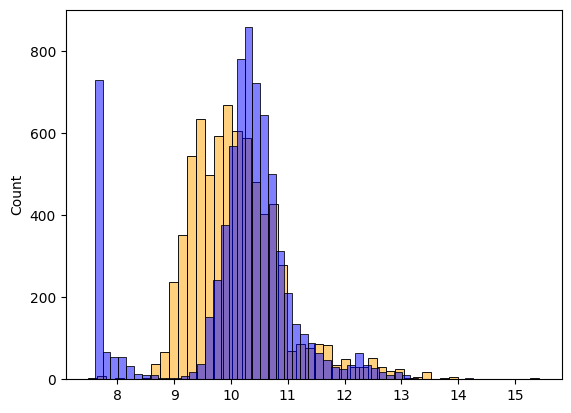

In [ ]:
sns.histplot(y_pred, color='orange', alpha=0.5, bins=50)
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)


# 2.9 RMSE

In [ ]:
y_test

array([ 9.9117533 ,  7.60140233, 10.43854715, ..., 10.24249229,
        9.62383979, 10.10810047], shape=(2382,))

In [ ]:
# Root Mean Squared Error (RMSE)
def rmse(y, y_pred):
    se = (y - y_pred) ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [ ]:
y_pred

array([ 9.30921267,  9.60412491, 10.45685179, ...,  8.96575185,
        9.71702037,  9.6295374 ], shape=(7150,))

In [ ]:
root_result = rmse(y_train, y_pred)
round(root_result, 2)

np.float64(0.75)

In [ ]:
base

['engine_hp', 'engine_cylinders', 'highway_mpg', 'city_mpg', 'popularity']

In [ ]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [ ]:
df_train[base].head()

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,230.0,8.0,15,12,1851
1,173.0,4.0,26,19,1851
2,250.0,4.0,28,23,640
3,455.0,8.0,25,16,1385
4,141.0,4.0,32,27,2202


In [ ]:
X_train = prepare_X(df_train)
X_train[:5]

array([[ 230.,    8.,   15.,   12., 1851.],
       [ 173.,    4.,   26.,   19., 1851.],
       [ 250.,    4.,   28.,   23.,  640.],
       [ 455.,    8.,   25.,   16., 1385.],
       [ 141.,    4.,   32.,   27., 2202.]])

In [ ]:
w0, w = train_linear_regression(X_train, y_train)
w0, w

(np.float64(7.855757074668947),
 array([ 9.44591324e-03, -1.38136594e-01,  1.43100524e-02,  1.76246210e-02,
        -2.16952658e-05]))

In [ ]:
rmse(y_train, y_pred)

np.float64(0.7488371491997372)

In [ ]:
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
X_val, y_pred

(array([[ 185.,    4.,   34.,   26., 2202.],
        [ 572.,    8.,   23.,   13.,  520.],
        [ 174.,    4.,   42.,   31., 2202.],
        ...,
        [ 200.,    6.,   27.,   19., 1851.],
        [ 132.,    4.,   36.,   28., 1439.],
        [ 175.,    6.,   16.,   14., 1851.]], shape=(2382, 5)),
 array([ 9.9477136 , 12.70069643, 10.04641208, ...,  9.59720143,
         9.52750303,  9.11551992], shape=(2382,)))

In [ ]:
rmse(y_val, y_pred)

np.float64(0.7700605899180485)

In [ ]:
np.expm1(y_train)

array([ 2000., 20695., 33095., ...,  2774., 30065., 20195.], shape=(7150,))

In [ ]:
np.expm1(y_pred)

array([ 20903.37192402, 327975.23600697,  23071.85454357, ...,
        14722.51910945,  13731.25922578,   9094.36226491], shape=(2382,))

In [ ]:
# def prepare_X(df):
#     df_num = df[base]
#     df_num = df_num.fillna(0)
#     X = df_num.values
#     return X

In [ ]:
df_test[base].isna().sum()

engine_hp           18
engine_cylinders     7
highway_mpg          0
city_mpg             0
popularity           0
dtype: int64

In [ ]:
filled_na = df_test[base].fillna(0)
filled_na.isna().sum()

engine_hp           0
engine_cylinders    0
highway_mpg         0
city_mpg            0
popularity          0
dtype: int64

In [ ]:
new_X_filled_na = filled_na.values
new_X_filled_na

array([[ 130.,    4.,   38.,   32., 2202.],
       [ 140.,    4.,   29.,   21., 2009.],
       [ 240.,    6.,   18.,   14.,  190.],
       ...,
       [ 170.,    4.,   34.,   25.,  873.],
       [ 148.,    4.,   33.,   24., 1385.],
       [ 261.,    6.,   22.,   16., 2009.]], shape=(2382, 5))

In [ ]:
df_test[base].head()

,engine_hp,engine_cylinders,highway_mpg,city_mpg,popularity
0,130.0,4.0,38,32,2202
1,140.0,4.0,29,21,2009
2,240.0,6.0,18,14,190
3,420.0,8.0,20,14,549
4,202.0,6.0,18,13,5657


In [ ]:
X_test = df_test[base].values
X_test[:5]

array([[1.300e+02, 4.000e+00, 3.800e+01, 3.200e+01, 2.202e+03],
       [1.400e+02, 4.000e+00, 2.900e+01, 2.100e+01, 2.009e+03],
       [2.400e+02, 6.000e+00, 1.800e+01, 1.400e+01, 1.900e+02],
       [4.200e+02, 8.000e+00, 2.000e+01, 1.400e+01, 5.490e+02],
       [2.020e+02, 6.000e+00, 1.800e+01, 1.300e+01, 5.657e+03]])

In [ ]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,Dodge,RAM 150,1992,regular unleaded,230.0,8.0,MANUAL,four wheel drive,2.0,NaN,Large,Extended Cab Pickup,15,12,1851
1,Dodge,Journey,2015,regular unleaded,173.0,4.0,AUTOMATIC,front wheel drive,4.0,Crossover,Midsize,4dr SUV,26,19,1851
2,Subaru,Forester,2015,premium unleaded (required),250.0,4.0,AUTOMATIC,all wheel drive,4.0,Crossover,Midsize,4dr SUV,28,23,640
3,Chevrolet,Camaro,2017,premium unleaded (recommended),455.0,8.0,MANUAL,rear wheel drive,2.0,High-Performance,Midsize,Coupe,25,16,1385
4,Honda,HR-V,2016,regular unleaded,141.0,4.0,AUTOMATIC,all wheel drive,4.0,Crossover,Compact,4dr SUV,32,27,2202
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7145,Toyota,Venza,2014,regular unleaded,268.0,6.0,AUTOMATIC,all wheel drive,4.0,"Crossover,Performance",Midsize,Wagon,25,18,2031
7146,Nissan,Titan,2017,regular unleaded,390.0,8.0,AUTOMATIC,rear wheel drive,4.0,NaN,Large,Crew Cab Pickup,21,15,2009
7147,Ford,Bronco,1996,regular unleaded,199.0,8.0,MANUAL,four wheel drive,2.0,NaN,Midsize,2dr SUV,16,13,5657
7148,Mazda,MX-5 Miata,2016,premium unleaded (recommended),155.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Convertible,34,27,586


# 2.10 Feature Engineering

In [ ]:
def prepare_X(df):
    df = df.copy()

    df['age'] = 2017 - df['year']
    features = base + ['age']

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [ ]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

In [ ]:
sns.histplot(y_pred, label='prediction', color='red', alpha=0.5, bins=50)
sns.histplot(y_val, label='target', color='blue',  alpha=0.5, bins=50)
plt.legend()

# 2.11 Categorical variables

In [ ]:
categorical_columns = [
    'make', 'model', 'engine_fuel_type', 'driven_wheels', 'market_category',
    'vehicle_size', 'vehicle_style']

categorical = {}

for c in categorical_columns:
    categorical[c] = list(df_train[c].value_counts().head().index)

In [ ]:
df_train[categorical_columns]

,make,model,engine_fuel_type,driven_wheels,market_category,vehicle_size,vehicle_style
0,Dodge,RAM 150,regular unleaded,four wheel drive,NaN,Large,Extended Cab Pickup
1,Dodge,Journey,regular unleaded,front wheel drive,Crossover,Midsize,4dr SUV
2,Subaru,Forester,premium unleaded (required),all wheel drive,Crossover,Midsize,4dr SUV
3,Chevrolet,Camaro,premium unleaded (recommended),rear wheel drive,High-Performance,Midsize,Coupe
4,Honda,HR-V,regular unleaded,all wheel drive,Crossover,Compact,4dr SUV
...,...,...,...,...,...,...,...
7145,Toyota,Venza,regular unleaded,all wheel drive,"Crossover,Performance",Midsize,Wagon
7146,Nissan,Titan,regular unleaded,rear wheel drive,NaN,Large,Crew Cab Pickup
7147,Ford,Bronco,regular unleaded,four wheel drive,NaN,Midsize,2dr SUV
7148,Mazda,MX-5 Miata,premium unleaded (recommended),rear wheel drive,Performance,Compact,Convertible


In [ ]:
categorical

{'make': ['Chevrolet', 'Ford', 'Volkswagen', 'Toyota', 'Dodge'],
 'model': ['Silverado 1500', 'Tundra', 'F-150', 'Sierra 1500', 'Beetle'],
 'engine_fuel_type': ['regular unleaded',
  'premium unleaded (required)',
  'premium unleaded (recommended)',
  'flex-fuel (unleaded/E85)',
  'diesel'],
 'driven_wheels': ['front wheel drive',
  'rear wheel drive',
  'all wheel drive',
  'four wheel drive'],
 'market_category': ['Crossover',
  'Flex Fuel',
  'Luxury',
  'Luxury,Performance',
  'Hatchback'],
 'vehicle_size': ['Compact', 'Midsize', 'Large'],
 'vehicle_style': ['Sedan',
  '4dr SUV',
  'Coupe',
  'Convertible',
  '4dr Hatchback']}

In [ ]:
def prepare_X(df):
    df = df.copy()

    df['age'] = 2017 - df['year']
    features = base + ['age']

    for v in [2, 3, 4]:
        df['num_doors_%d' % v] = (df.number_of_doors == v).astype(int)
        features.append('num_doors_%d' % v)

    for name, values in categorical.items():
        for value in values:
            df['%s_%s' % (name, value)] = (df[name] == value).astype(int)
            features.append('%s_%s' % (name, value))

    df_num = df[features]
    df_num = df_num.fillna(0)
    X = df_num.values

    return X

In [ ]:
X_train

array([[2.300e+02, 8.000e+00, 1.500e+01, 1.200e+01, 1.851e+03],
       [1.730e+02, 4.000e+00, 2.600e+01, 1.900e+01, 1.851e+03],
       [2.500e+02, 4.000e+00, 2.800e+01, 2.300e+01, 6.400e+02],
       ...,
       [1.990e+02, 8.000e+00, 1.600e+01, 1.300e+01, 5.657e+03],
       [1.550e+02, 4.000e+00, 3.400e+01, 2.700e+01, 5.860e+02],
       [1.700e+02, 5.000e+00, 3.300e+01, 2.300e+01, 8.730e+02]],
      shape=(7150, 5))

In [ ]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(211.8957873859309)

In [ ]:
w0, w

# 2.12 Regularization

In [ ]:
X = [
    [4, 4, 4],
    [3, 5, 5],
    [5, 1, 1],
    [5, 4, 4],
    [7, 5, 5],
    [4, 5, 5],
]

X = np.array(X)
X

array([[4, 4, 4],
       [3, 5, 5],
       [5, 1, 5],
       [5, 4, 5],
       [7, 5, 5],
       [4, 5, 5]])

In [ ]:
y= [1, 2, 3, 1, 2, 3]

In [ ]:
XTX = X.T.dot(X)
XTX

array([[140, 111, 136],
       [111, 108, 116],
       [136, 116, 141]])

In [ ]:
XTX_inv = np.linalg.inv(XTX)
XTX_inv

array([[ 0.11415319,  0.00805257, -0.11673001],
       [ 0.00805257,  0.08013915, -0.07369709],
       [-0.11673001, -0.07369709,  0.18031308]])

In [ ]:
X.T

array([[4, 3, 5, 5, 7, 4],
       [4, 5, 1, 4, 5, 5],
       [4, 5, 5, 5, 5, 5]])

In [ ]:
XTX_inv.dot(X.T).dot(y)

array([-0.12407395, -0.210784  ,  0.71152483])

In [ ]:
r=0.001
r * np.eye(XTX.shape[0])
r

0.001

In [ ]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [ ]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

In [ ]:
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
rmse(y_val, y_pred)

np.float64(0.4734878865276723)

In [496]:
y_val, y_pred

(array([ 8.03915739, 10.70461432, 11.12137805, ..., 11.67445741,
        10.45452378, 11.39640288], shape=(2382,)),
 array([ 9.7039377 , 12.165075  , 10.43700916, ...,  9.25834512,
         9.49780532,  7.90557174], shape=(2382,)))

# 2.13 Tuning Model

In [ ]:
for r in [0.0, 0.00001, 0.0001, 0.001, 0.1, 1, 10, 100, 200]:
    X_train = prepare_X(df_train)
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)

    X_val = prepare_X(df_val)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_val, y_pred)

    print(f'r: {r}, score: {round(score, 2)}')

r: 0.0, score: 211.9
r: 1e-05, score: 0.47
r: 0.0001, score: 0.47
r: 0.001, score: 0.47
r: 0.1, score: 0.47
r: 1, score: 0.48
r: 10, score: 0.49
r: 100, score: 0.61
r: 200, score: 0.72


# Using Model

In [498]:
df_val

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,Ford,F-250,1998,regular unleaded,220.0,8.0,MANUAL,four wheel drive,2.0,NaN,Large,Regular Cab Pickup,16,13,5657
1,Lincoln,Continental,2017,regular unleaded,305.0,6.0,AUTOMATIC,front wheel drive,4.0,Luxury,Large,Sedan,26,17,61
2,Land Rover,Range Rover Sport,2014,flex-fuel (premium unleaded required/E85),340.0,6.0,AUTOMATIC,four wheel drive,4.0,"Flex Fuel,Luxury,Performance",Midsize,4dr SUV,23,17,258
3,BMW,4 Series,2015,premium unleaded (required),240.0,4.0,AUTOMATIC,rear wheel drive,2.0,Luxury,Midsize,Convertible,34,23,3916
4,Volkswagen,Passat,2015,diesel,150.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Diesel,Midsize,Sedan,42,30,873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,Infiniti,G Sedan,2012,premium unleaded (recommended),328.0,6.0,AUTOMATIC,all wheel drive,4.0,Luxury,Midsize,Sedan,25,18,190
2378,Volkswagen,Golf GTI,2016,premium unleaded (recommended),210.0,4.0,AUTOMATED_MANUAL,front wheel drive,2.0,"Hatchback,Performance",Compact,2dr Hatchback,33,25,873
2379,Porsche,911,2016,premium unleaded (required),400.0,6.0,MANUAL,all wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,26,18,1715
2380,Toyota,Tacoma,2016,regular unleaded,278.0,6.0,AUTOMATIC,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,23,18,2031


In [499]:
df_full_train = pd.concat([df_train, df_val])
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,Volkswagen,Jetta Hybrid,2013,premium unleaded (required),170.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Hybrid,Midsize,Sedan,48,42,873
1,Nissan,Frontier,2016,regular unleaded,261.0,6.0,MANUAL,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,21,16,2009
2,BMW,Z3,2000,regular unleaded,193.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,24,17,3916
3,Pontiac,Solstice,2008,regular unleaded,173.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Convertible,25,19,210
4,BMW,6 Series,2017,premium unleaded (required),315.0,6.0,AUTOMATIC,all wheel drive,2.0,"Luxury,Performance",Midsize,Coupe,28,19,3916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2377,Infiniti,G Sedan,2012,premium unleaded (recommended),328.0,6.0,AUTOMATIC,all wheel drive,4.0,Luxury,Midsize,Sedan,25,18,190
2378,Volkswagen,Golf GTI,2016,premium unleaded (recommended),210.0,4.0,AUTOMATED_MANUAL,front wheel drive,2.0,"Hatchback,Performance",Compact,2dr Hatchback,33,25,873
2379,Porsche,911,2016,premium unleaded (required),400.0,6.0,MANUAL,all wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,26,18,1715
2380,Toyota,Tacoma,2016,regular unleaded,278.0,6.0,AUTOMATIC,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,23,18,2031


In [500]:
df_full_train = df_full_train.reset_index(drop=True)
df_full_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity
0,Volkswagen,Jetta Hybrid,2013,premium unleaded (required),170.0,4.0,AUTOMATED_MANUAL,front wheel drive,4.0,Hybrid,Midsize,Sedan,48,42,873
1,Nissan,Frontier,2016,regular unleaded,261.0,6.0,MANUAL,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,21,16,2009
2,BMW,Z3,2000,regular unleaded,193.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,24,17,3916
3,Pontiac,Solstice,2008,regular unleaded,173.0,4.0,MANUAL,rear wheel drive,2.0,Performance,Compact,Convertible,25,19,210
4,BMW,6 Series,2017,premium unleaded (required),315.0,6.0,AUTOMATIC,all wheel drive,2.0,"Luxury,Performance",Midsize,Coupe,28,19,3916
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9527,Infiniti,G Sedan,2012,premium unleaded (recommended),328.0,6.0,AUTOMATIC,all wheel drive,4.0,Luxury,Midsize,Sedan,25,18,190
9528,Volkswagen,Golf GTI,2016,premium unleaded (recommended),210.0,4.0,AUTOMATED_MANUAL,front wheel drive,2.0,"Hatchback,Performance",Compact,2dr Hatchback,33,25,873
9529,Porsche,911,2016,premium unleaded (required),400.0,6.0,MANUAL,all wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,26,18,1715
9530,Toyota,Tacoma,2016,regular unleaded,278.0,6.0,AUTOMATIC,four wheel drive,4.0,NaN,Compact,Crew Cab Pickup,23,18,2031


In [501]:
X_full_train = prepare_X(df_full_train)
X_full_train

array([[170.,   4.,  48., ...,   0.,   0.,   0.],
       [261.,   6.,  21., ...,   0.,   0.,   0.],
       [193.,   6.,  24., ...,   0.,   1.,   0.],
       ...,
       [400.,   6.,  26., ...,   1.,   0.,   0.],
       [278.,   6.,  23., ...,   0.,   0.,   0.],
       [290.,   6.,  22., ...,   1.,   0.,   0.]], shape=(9532, 41))

In [502]:
y_train

array([10.20325876, 10.27128541,  8.51258258, ..., 10.67616192,
        9.89802265, 10.44322128], shape=(7150,))

In [503]:
y_full_train = np.concatenate([y_train, y_val])

In [504]:
y_full_train

array([10.20325876, 10.27128541,  8.51258258, ..., 11.67445741,
       10.45452378, 11.39640288], shape=(9532,))

In [505]:
np.expm1(y_full_train)

array([ 26990.,  28890.,   4976., ..., 117530.,  34700.,  89000.],
      shape=(9532,))

In [ ]:
w0, w = train_linear_regression_reg(X_full_train, y_full_train, r=0.001)

In [ ]:
w

In [ ]:
df_test

In [ ]:
X_test = prepare_X(df_test)
y_pred = w0 + X_test.dot(w)
score = rmse(y_test, y_pred)
score

In [ ]:
car = df_test.iloc[20].to_dict()
car

In [ ]:
df_small = pd.DataFrame([car])
df_small

In [ ]:
X_small = prepare_X(df_small)
X_small

In [ ]:
y_pred = w0 + X_small.dot(w)
y_pred[0]

In [ ]:
y_test #  msrp.values from dataframe df_test

In [ ]:
car

In [ ]:
np.expm1(y_test[20])

In [ ]:
np.expm1(y_pred[0])